In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

mnist = pd.read_csv("data/mnist-train.csv")
mnist

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
X = mnist.drop(columns = "label").copy()
y = mnist["label"].copy()

In [3]:
X = X / 255

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [5]:
X_train.shape

(33600, 784)

In [6]:
def create_batches(X, y, size = 128):
    if X.shape[0] != y.shape[0]:
        raise Exception("Num. de muestras no concuerdan en X y y")
    ini = 0
    samples = X.shape[0]
    batches = [(X[i:i+size], y[i:i+size]) for i in range(0, samples, size)]
    return batches

In [7]:
training_data = create_batches(X_train, y_train)
len(training_data)

263

# My Implementation of Neural Networks

In [8]:
from classes.MyNeuralNetwork import MyNeuralNetworkClassifier

my_nn = MyNeuralNetworkClassifier([50, 20], X.shape[-1], classes = 10)

In [9]:
start_time = time.perf_counter()
my_loss = []
for (batch_x, batch_y) in training_data:
    loss = my_nn.fit(batch_x, batch_y, return_loss = True)
    my_loss.append(loss)
end_time = time.perf_counter()
print(f"Traning time of my model is {end_time-start_time:.2f} seconds")

Traning time of my model is 96.50 seconds


In [10]:
print(my_loss[-5:])

[0.063801400145, 0.0764545454228211, 0.08657889826355422, 0.028336006530434228, 0.014108696519760273]


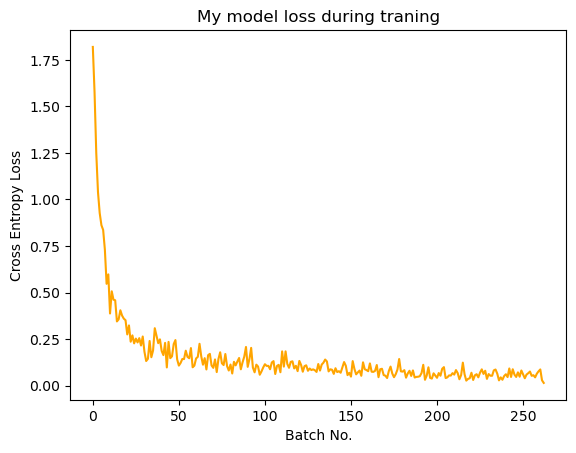

In [35]:
plt.figure()
plt.plot(range(len(my_loss)), my_loss, c = "orange")
plt.title("My model loss during traning")
plt.xlabel("Batch No.")
plt.ylabel("Cross Entropy Loss")

plt.savefig("images/my-training-loss.jpg")

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix

predictions = my_nn.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, predictions))


Accuracy score: 0.9373809523809524


In [14]:
my_conf_matrix = confusion_matrix(y_test, predictions)

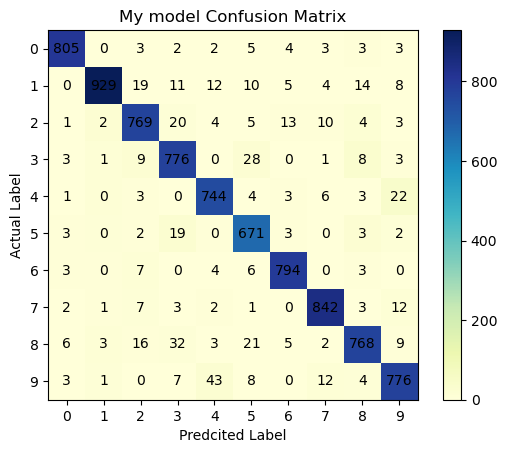

In [15]:
plt.figure()
plt.imshow(my_conf_matrix, cmap = "YlGnBu")
plt.xticks(range(10))
plt.yticks(range(10))
plt.ylabel("Actual Label")
plt.xlabel("Predcited Label")
plt.colorbar()
plt.title("My model Confusion Matrix")

for i in range(10):
    for j in range(10):
        plt.text(i, j, my_conf_matrix[i, j], ha = "center", va = "center", color = "black")
plt.savefig("images/my-nn-test-heatmap.jpg")

In [16]:
def incorrect_example(X_data, y_true, y_hat):
    mask = (y_true != y_hat)
    incorrect = y_true[mask]
    incorrect_predictions = y_hat[mask]
    pos = np.random.randint(0, incorrect.shape[0])
    idx = incorrect[pos:pos+1].index
    num = X_data.loc[idx].to_numpy().reshape((28, 28))
    plt.imshow(num, cmap = plt.get_cmap("gray"))
    plt.show()
    print("Label:", y_test.loc[idx])
    print("Predicted:", incorrect_predictions[pos])

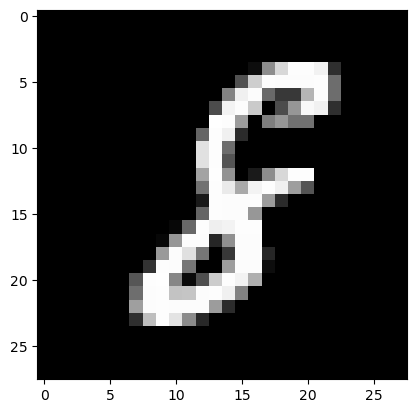

Label: 26834    8
Name: label, dtype: int64
Predicted: 1


In [17]:
incorrect_example(X_test, y_test, predictions)

# Scikit Learn Model

In [28]:
from sklearn.neural_network import MLPClassifier

sklear_nn = MLPClassifier([50, 20], batch_size = 128, solver = "sgd")

In [29]:
start_time = time.perf_counter()
sklear_nn.fit(X_train, y_train)
end_time = time.perf_counter()
print(f"Traning time of scikit learn: {end_time-start_time:.2f} seconds")

Traning time of scikit learn: 491.17 seconds


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [30]:
sklearn_predictions = sklear_nn.predict(X_test)
print("Sklearn accuracy:", accuracy_score(y_test, sklearn_predictions))

Sklearn accuracy: 0.9657142857142857


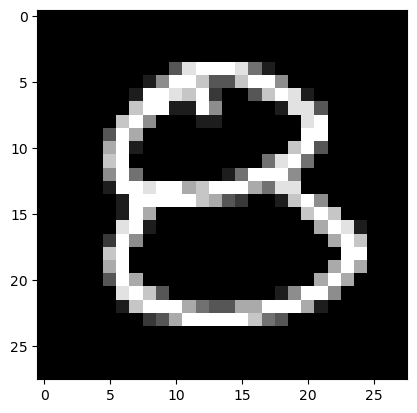

Label: 8067    8
Name: label, dtype: int64
Predicted: 3


In [31]:
incorrect_example(X_test, y_test, sklearn_predictions)

In [32]:
sklearn_conf_matrix = confusion_matrix(y_test, sklearn_predictions)

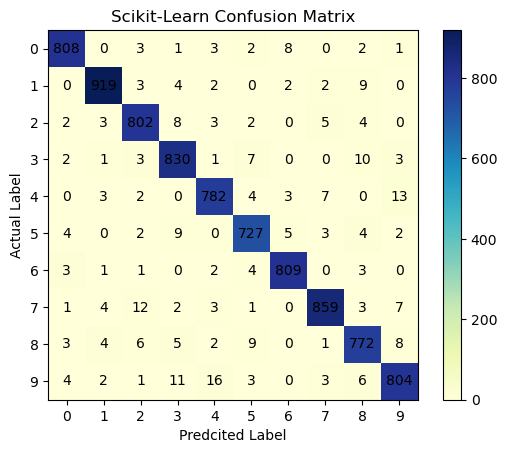

In [33]:
plt.figure()
plt.imshow(sklearn_conf_matrix, cmap = "YlGnBu")
plt.xticks(range(10))
plt.yticks(range(10))
plt.ylabel("Actual Label")
plt.xlabel("Predcited Label")
plt.colorbar()
plt.title("Scikit-Learn Confusion Matrix")

for i in range(10):
    for j in range(10):
        plt.text(i, j, sklearn_conf_matrix[i, j], ha = "center", va = "center", color = "black")
plt.savefig("images/sklearn-nn-test-heatmap.jpg")

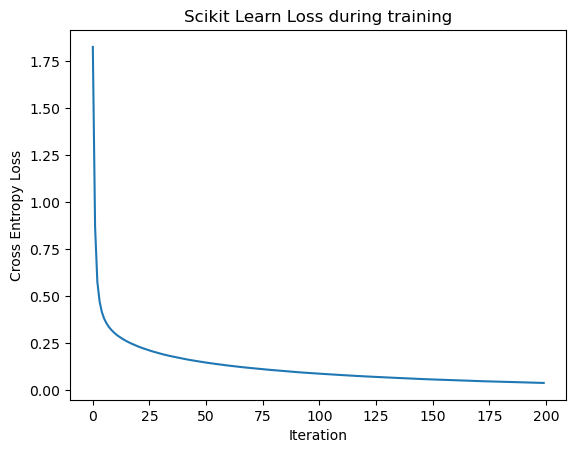

In [ ]:
sklearn_loss = sklear_nn.loss_curve_
plt.plot(range(len(sklearn_loss)), sklearn_loss)
plt.title("Scikit Learn Loss during training")
plt.xlabel("Iteration")
plt.ylabel("Cross Entropy Loss")
plt.savefig("images/sklearn-traning-loss.jpg")